In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.dummy import DummyClassifier

In [2]:
# loading employee attrition dataset
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
# checking dataset shape
df.shape

(1470, 35)

In [4]:
# displaying first five rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Understanding

In [5]:
# checking dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# checking column names
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
# checking summary statistics
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
# checking statistical summary of categorical columns
df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


## Target Variable Understanding

Yes = employee left,
No = employee stayed

In [9]:
# checking attrition class distribution
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [10]:
# checking attrition class percentage
df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


## Data Quality Checks

In [11]:
# checking missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [12]:
# checking duplicate records
df.duplicated().sum()

np.int64(0)

In [13]:
# checking number of unique values in each column
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


## Data Dictionary and Feature Grouping

In [14]:
# creating ordinal value mappings for interpretation
ordinal_mappings = {
    "Education": {
        1: "Below College",
        2: "College",
        3: "Bachelor",
        4: "Master",
        5: "Doctor"
    },
    "EnvironmentSatisfaction": {
        1: "Low",
        2: "Medium",
        3: "High",
        4: "Very High"
    },
    "JobInvolvement": {
        1: "Low",
        2: "Medium",
        3: "High",
        4: "Very High"
    },
    "JobSatisfaction": {
        1: "Low",
        2: "Medium",
        3: "High",
        4: "Very High"
    },
    "PerformanceRating": {
        1: "Low",
        2: "Good",
        3: "Excellent",
        4: "Outstanding"
    },
    "RelationshipSatisfaction": {
        1: "Low",
        2: "Medium",
        3: "High",
        4: "Very High"
    },
    "WorkLifeBalance": {
        1: "Bad",
        2: "Good",
        3: "Better",
        4: "Best"
    }
}

In [15]:
# grouping dataset features according to their role and data type
target_col = "Attrition"
identifier_cols = [
    "EmployeeNumber"
]

constant_cols = [
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

nominal_categorical_cols = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

ordinal_cols = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "JobLevel",
    "StockOptionLevel"
]

numerical_cols = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

In [16]:
# creating a data dictionary for dataset understanding
feature_groups = {}

for col in df.columns:
    if col == target_col:
        feature_groups[col] = "Target Variable"
    elif col in identifier_cols:
        feature_groups[col] = "Identifier Column"
    elif col in constant_cols:
        feature_groups[col] = "Constant Column"
    elif col in nominal_categorical_cols:
        feature_groups[col] = "Nominal Categorical Feature"
    elif col in ordinal_cols:
        feature_groups[col] = "Ordinal Feature"
    elif col in numerical_cols:
        feature_groups[col] = "Numerical Feature"
    else:
        feature_groups[col] = "Other Feature"

data_dictionary = pd.DataFrame({
    "Column_Name": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Feature_Group": [feature_groups[col] for col in df.columns],
    "Unique_Values": [df[col].nunique() for col in df.columns],
    "Missing_Values": [df[col].isnull().sum() for col in df.columns],
    "Sample_Values": [df[col].dropna().unique()[:5] for col in df.columns]
})

data_dictionary

,Column_Name,Data_Type,Feature_Group,Unique_Values,Missing_Values,Sample_Values
0,Age,int64,Numerical Feature,43,0,"[41, 49, 37, 33, 27]"
1,Attrition,object,Target Variable,2,0,"[Yes, No]"
2,BusinessTravel,object,Nominal Categorical Feature,3,0,"[Travel_Rarely, Travel_Frequently, Non-Travel]"
3,DailyRate,int64,Numerical Feature,886,0,"[1102, 279, 1373, 1392, 591]"
4,Department,object,Nominal Categorical Feature,3,0,"[Sales, Research & Development, Human Resources]"
5,DistanceFromHome,int64,Numerical Feature,29,0,"[1, 8, 2, 3, 24]"
6,Education,int64,Ordinal Feature,5,0,"[2, 1, 4, 3, 5]"
7,EducationField,object,Nominal Categorical Feature,6,0,"[Life Sciences, Other, Medical, Marketing, Tec..."
8,EmployeeCount,int64,Constant Column,1,0,[1]
9,EmployeeNumber,int64,Identifier Column,1470,0,"[1, 2, 4, 5, 7]"


In [17]:
# displaying feature groups used in the project
feature_group_summary = pd.DataFrame({
    "Feature_Group": [
        "Target Variable",
        "Identifier Column",
        "Constant Columns",
        "Nominal Categorical Features",
        "Ordinal Features",
        "Numerical Features"
    ],
    "Columns": [
        target_col,
        identifier_cols,
        constant_cols,
        nominal_categorical_cols,
        ordinal_cols,
        numerical_cols
    ],
    "Count": [
        1,
        len(identifier_cols),
        len(constant_cols),
        len(nominal_categorical_cols),
        len(ordinal_cols),
        len(numerical_cols)
    ]
})

feature_group_summary

,Feature_Group,Columns,Count
0,Target Variable,Attrition,1
1,Identifier Column,[EmployeeNumber],1
2,Constant Columns,"[EmployeeCount, Over18, StandardHours]",3
3,Nominal Categorical Features,"[BusinessTravel, Department, EducationField, G...",7
4,Ordinal Features,"[Education, EnvironmentSatisfaction, JobInvolv...",9
5,Numerical Features,"[Age, DailyRate, DistanceFromHome, HourlyRate,...",14


In [18]:
# checking whether all grouped columns exist in the dataset
all_grouped_cols = (
    [target_col]
    + identifier_cols
    + constant_cols
    + nominal_categorical_cols
    + ordinal_cols
    + numerical_cols
)

missing_grouped_cols = [col for col in all_grouped_cols if col not in df.columns]
extra_dataset_cols = [col for col in df.columns if col not in all_grouped_cols]

print("Columns missing from dataset:", missing_grouped_cols)
print("Dataset columns not included in groups:", extra_dataset_cols)

Columns missing from dataset: []
Dataset columns not included in groups: []


In [19]:
# displaying ordinal mappings for report interpretation
ordinal_mapping_table = []

for feature, mapping in ordinal_mappings.items():
    for value, meaning in mapping.items():
        ordinal_mapping_table.append({
            "Feature": feature,
            "Encoded_Value": value,
            "Meaning": meaning
        })

ordinal_mapping_df = pd.DataFrame(ordinal_mapping_table)
ordinal_mapping_df

,Feature,Encoded_Value,Meaning
0,Education,1,Below College
1,Education,2,College
2,Education,3,Bachelor
3,Education,4,Master
4,Education,5,Doctor
5,EnvironmentSatisfaction,1,Low
6,EnvironmentSatisfaction,2,Medium
7,EnvironmentSatisfaction,3,High
8,EnvironmentSatisfaction,4,Very High
9,JobInvolvement,1,Low


## Exploratory Data Analysis

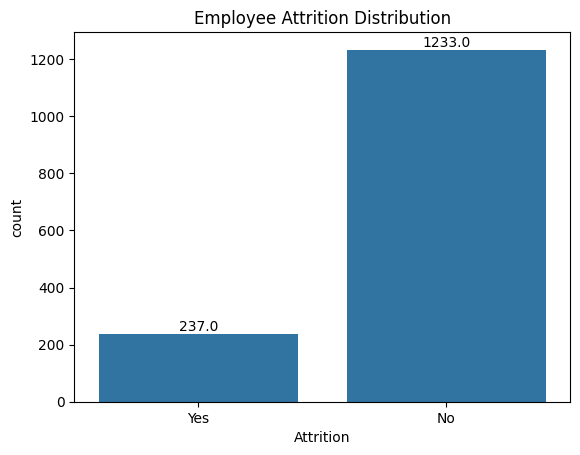

In [20]:
# plotting attrition distribution
ax = sns.countplot(data=df, x='Attrition')
plt.title("Employee Attrition Distribution")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

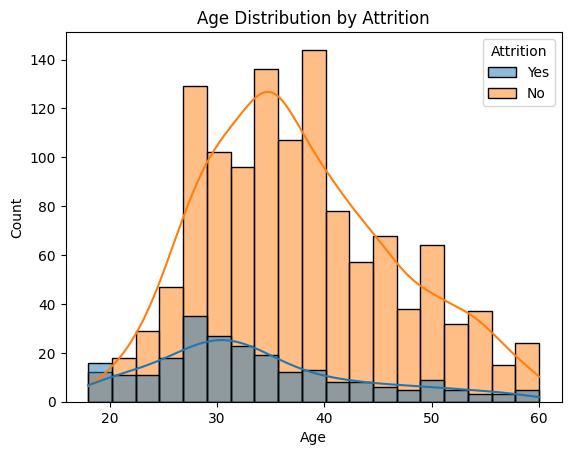

In [21]:
# plotting age distribution by attrition
sns.histplot(data=df, x='Age', hue='Attrition', kde=True)
plt.title("Age Distribution by Attrition")
plt.show()

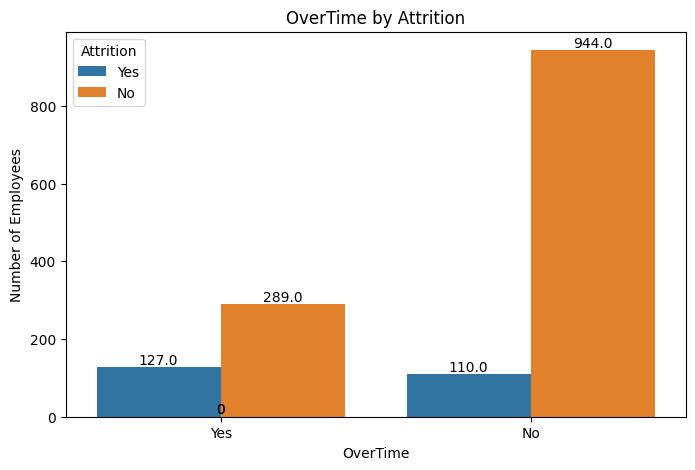

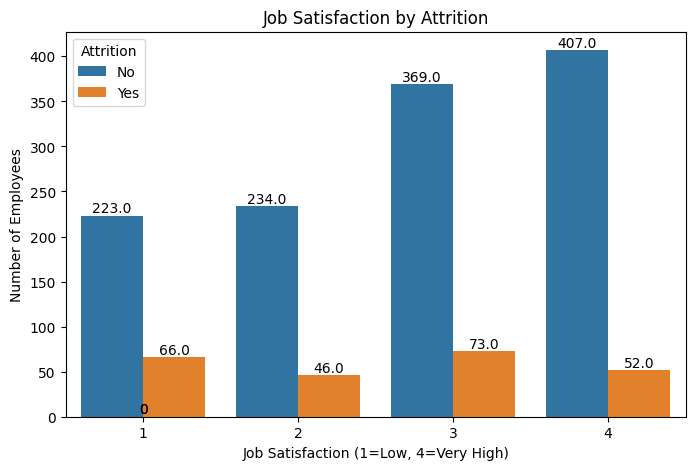

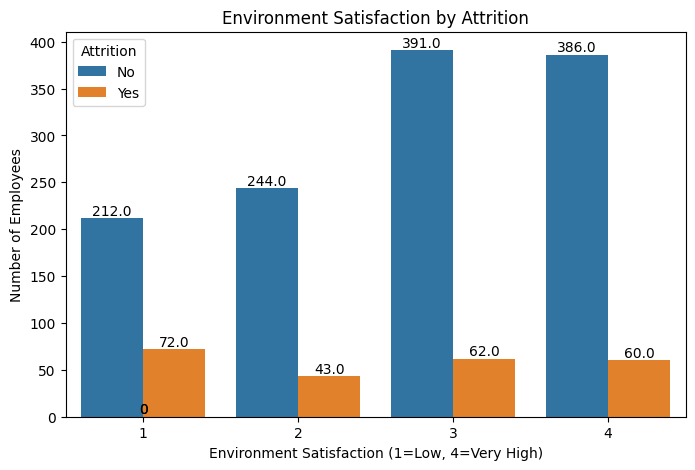

In [22]:
# Plotting OverTime by Attrition
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('OverTime by Attrition')
plt.ylabel('Number of Employees')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# Plotting JobSatisfaction by Attrition
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')
plt.title('Job Satisfaction by Attrition')
plt.xlabel('Job Satisfaction (1=Low, 4=Very High)')
plt.ylabel('Number of Employees')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# Plotting EnvironmentSatisfaction by Attrition
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='EnvironmentSatisfaction', hue='Attrition')
plt.title('Environment Satisfaction by Attrition')
plt.xlabel('Environment Satisfaction (1=Low, 4=Very High)')
plt.ylabel('Number of Employees')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

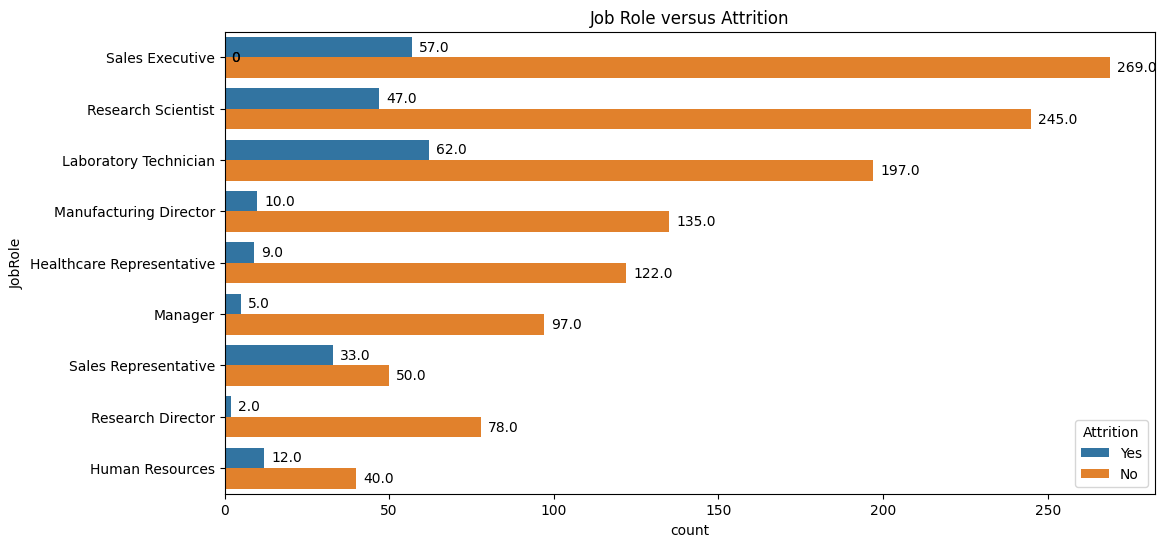

In [23]:
# plotting job role and attrition
plt.figure(figsize=(12,6))
ax = sns.countplot(data=df, y='JobRole', hue='Attrition')
plt.title("Job Role versus Attrition")
for p in ax.patches:
    ax.annotate(f'{p.get_width()}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                textcoords='offset points')

plt.show()

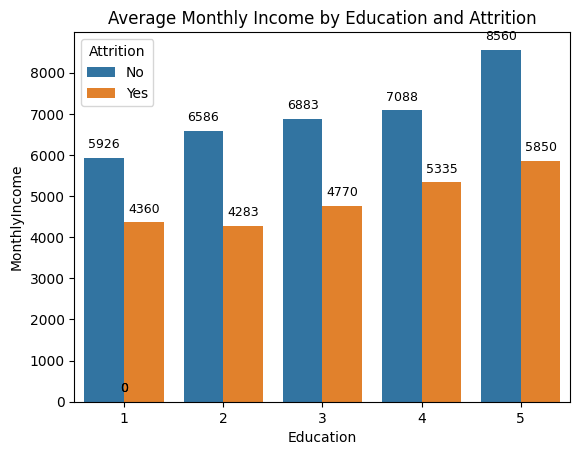

In [24]:
# comparing average monthly income by education and attrition
income_edu = df.groupby(['Education', 'Attrition'])['MonthlyIncome'].mean().reset_index()
ax = sns.barplot(data=income_edu, x='Education', y='MonthlyIncome', hue='Attrition')
plt.title("Average Monthly Income by Education and Attrition")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

## Outlier Analysis

In [25]:
# selecting numerical columns for outlier analysis
outlier_cols = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

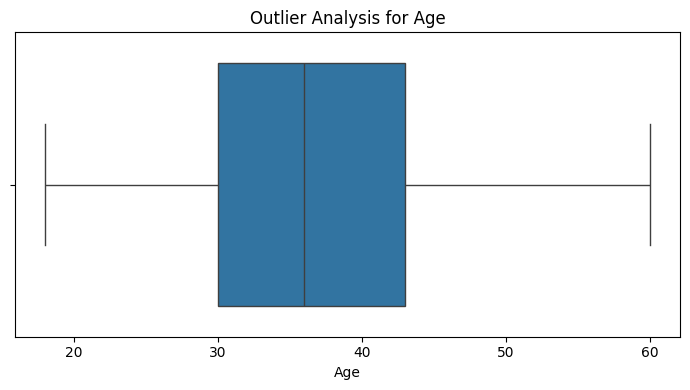

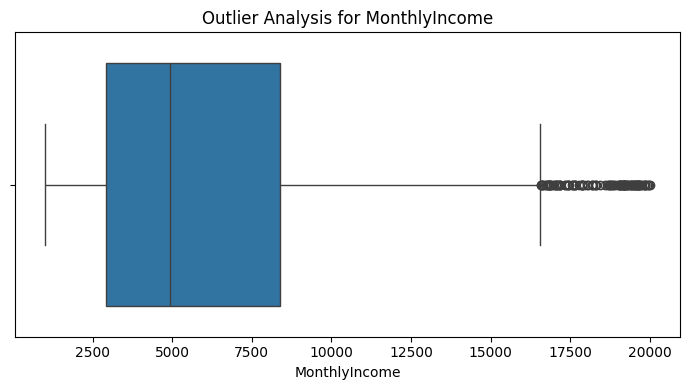

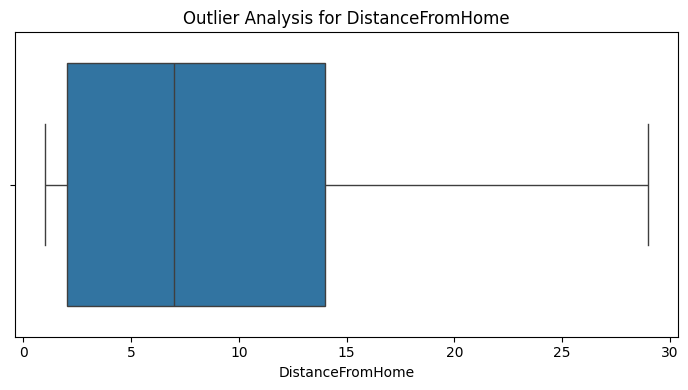

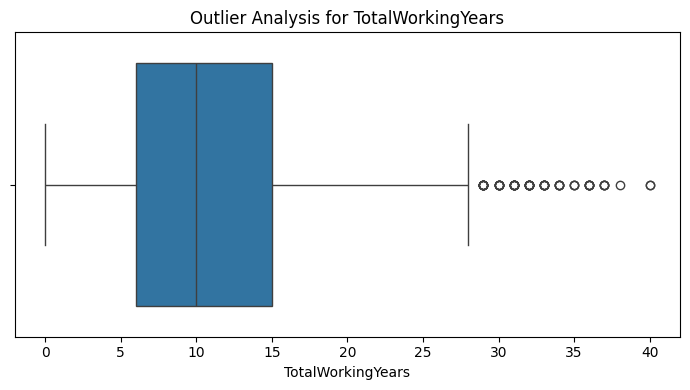

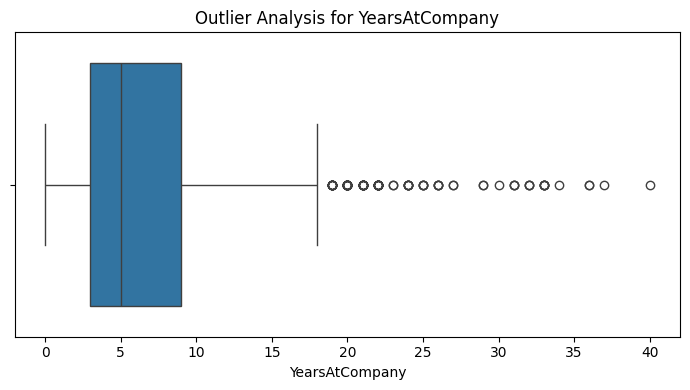

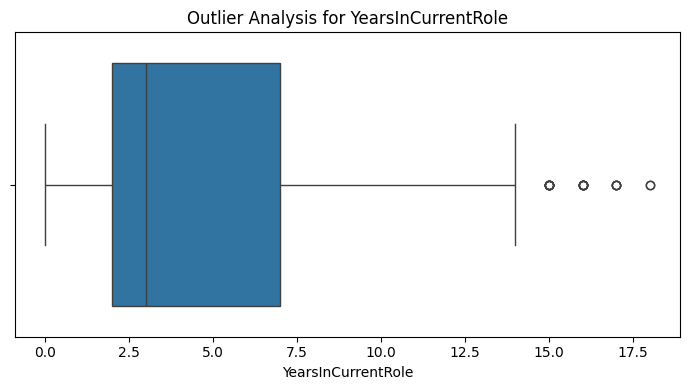

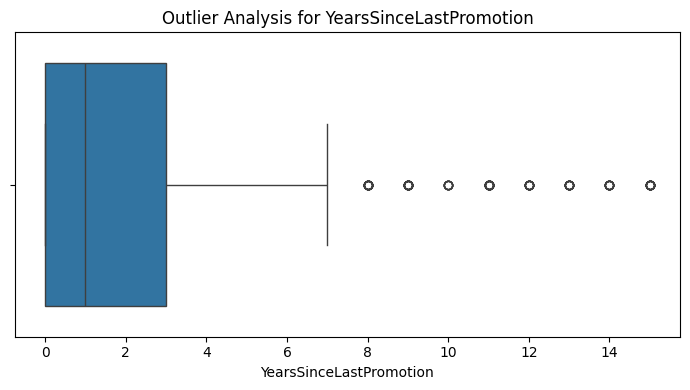

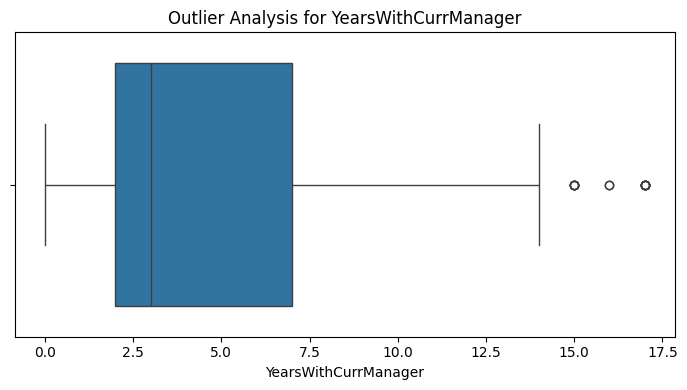

In [26]:
# creating boxplots for important numerical variables
for col in outlier_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Outlier Analysis for {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [27]:
# calculating outlier counts using IQR method
outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,10.5,62.5,0
1,MonthlyIncome,-5291.0,16581.0,114
2,DistanceFromHome,-16.0,32.0,0
3,TotalWorkingYears,-7.5,28.5,63
4,YearsAtCompany,-6.0,18.0,104
5,YearsInCurrentRole,-5.5,14.5,21
6,YearsSinceLastPromotion,-4.5,7.5,107
7,YearsWithCurrManager,-5.5,14.5,14


In [28]:
# creating encoded copy for correlation analysis
df_corr = df.copy()
df_corr["Attrition"] = df_corr["Attrition"].map({"Yes": 1, "No": 0})

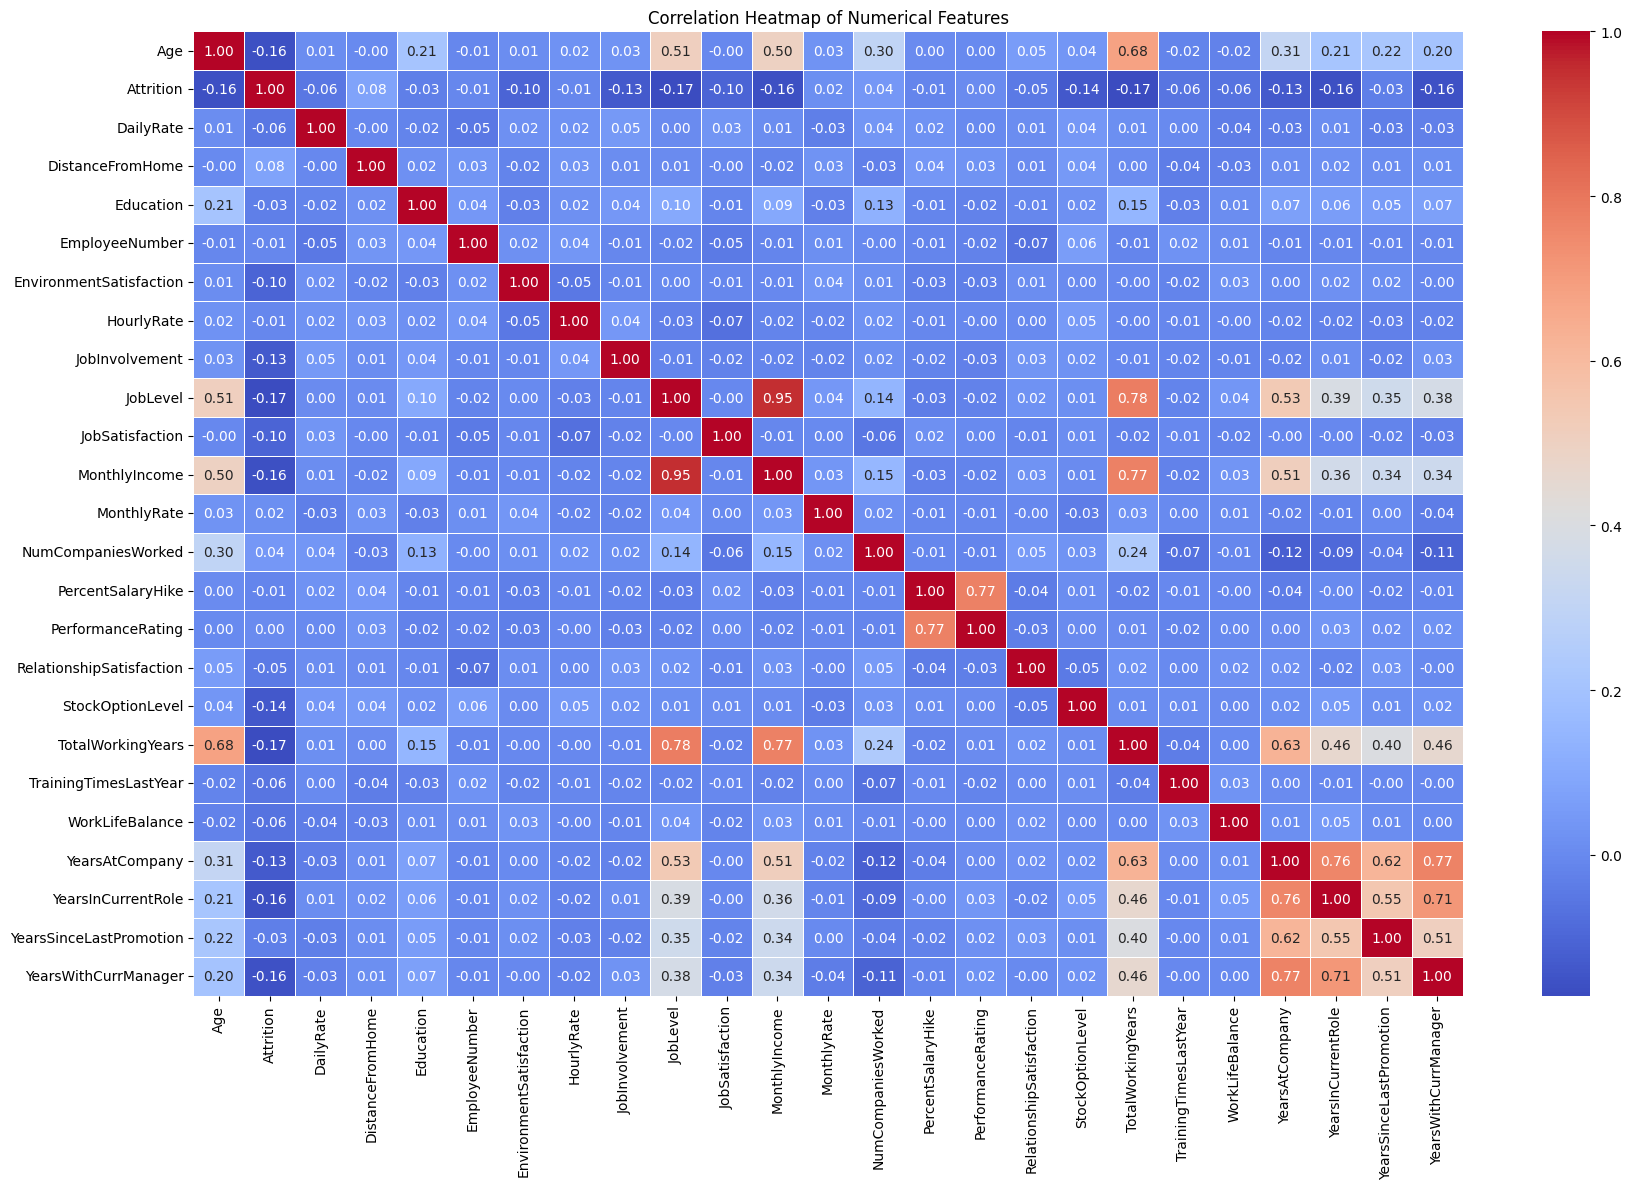

In [29]:
# plotting correlation heatmap for numerical features
numeric_df = df_corr.select_dtypes(include=np.number)
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]
corr_matrix = numeric_df.corr()
plt.figure(figsize=(18, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [30]:
# checking correlation with attrition target
target_corr = corr_matrix["Attrition"].sort_values(ascending=False)
target_corr

,Attrition
Attrition,1.000000
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
PerformanceRating,0.002889
HourlyRate,-0.006846
EmployeeNumber,-0.010577
PercentSalaryHike,-0.013478
Education,-0.031373
YearsSinceLastPromotion,-0.033019


## Data Pre-processing

In [31]:
# creating modelling dataset copy
df_model = df.copy()

In [32]:
# dropping identifier and constant columns
df_model = df_model.drop(["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"], axis=1)

In [33]:
# encoding target variable
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

1 = employee left,
0 = employee stayed

In [34]:
# checking updated dataset shape
df_model.shape

(1470, 31)

In [35]:
# separating independent and target variables
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

In [36]:
# identifying categorical and numerical columns for modelling
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical Features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [37]:
# splitting dataset into training and testing sets using stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=124,
    stratify=y
)

In [38]:
# calculating class imbalance ratio from training data
class_counts = y_train.value_counts()
majority_class_count = class_counts[0]
minority_class_count = class_counts[1]

scale_pos_weight = majority_class_count / minority_class_count

print("Class distribution in training data:")
print(class_counts)

print("\nScale positive weight for minority class:")
print(scale_pos_weight)

Class distribution in training data:
Attrition
0    986
1    190
Name: count, dtype: int64

Scale positive weight for minority class:
5.189473684210526


In [39]:
# creating manual class weight dictionary for imbalanced classification
class_weight_dict = {
    0: 1,
    1: scale_pos_weight
}

class_weight_dict

{0: 1, 1: np.float64(5.189473684210526)}

In [40]:
# checking train and test data shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1176, 30)
X_test shape: (294, 30)
y_train shape: (1176,)
y_test shape: (294,)


In [41]:
# checking target distribution in training and testing sets
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64

Testing target distribution:
Attrition
0    84.013605
1    15.986395
Name: proportion, dtype: float64


## Pre-processing Pipeline

In [42]:
# creating preprocessing pipeline for numerical and categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Feature Selection and Engineering

In [43]:
# checking correlation with target variable
corr_with_target = df_model.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)
corr_with_target

,Attrition
Attrition,1.000000
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
PerformanceRating,0.002889
HourlyRate,-0.006846
PercentSalaryHike,-0.013478
Education,-0.031373
YearsSinceLastPromotion,-0.033019
RelationshipSatisfaction,-0.045872


## Baseline Model

In [44]:
# creating baseline dummy classifier
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

In [45]:
dummy_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', DummyClassifier(strategy='most_frequent'))])

In [46]:
# predicting with baseline model
dummy_pred = dummy_model.predict(X_test)

In [47]:
# evaluating baseline model
baseline_results = {
    "Model": "Baseline Dummy Classifier",
    "Accuracy": accuracy_score(y_test, dummy_pred),
    "Precision": precision_score(y_test, dummy_pred, zero_division=0),
    "Recall": recall_score(y_test, dummy_pred, zero_division=0),
    "F1-Score": f1_score(y_test, dummy_pred, zero_division=0),
    "ROC-AUC": 0.5
}

baseline_results

{'Model': 'Baseline Dummy Classifier',
 'Accuracy': 0.8401360544217688,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-Score': 0.0,
 'ROC-AUC': 0.5}

## **Machine Learning Model** **Implementation**

## Logistic Regression

In [48]:
# creating logistic regression pipeline with class weights
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight=class_weight_dict,
        random_state=124
    ))
])

In [49]:
# creating logistic regression pipeline
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

## Decision Tree

In [50]:
# creating decision tree pipeline with class weights
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=124,
        class_weight=class_weight_dict,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2
    ))
])

## Random Forest

In [51]:
# creating random forest pipeline with balanced subsample class weights
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=124,
        class_weight="balanced_subsample",
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1
    ))
])

## Support Vector Machine

In [52]:
# creating support vector machine pipeline with class weights
svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        class_weight=class_weight_dict,
        random_state=124
    ))
])

## XGBoost

In [53]:
# creating xgboost pipeline
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=124,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1
    ))
])

## Neural Network

In [54]:
# importing multilayer perceptron classifier
from sklearn.neural_network import MLPClassifier

In [55]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=124)

ann_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        random_state=124
    ))
])

# Define the parameter grid for ANN
# MLPClassifier does not have a 'class_weight' parameter for direct use in param_grid.
# If addressing class imbalance for ANN, consider using sampling techniques (e.g., from imblearn).
ann_param_grid = {
    "classifier__hidden_layer_sizes": [(64,), (128, 64)],
    "classifier__activation": ["relu", "tanh"],
    "classifier__solver": ["adam"],
    "classifier__alpha": [0.0001, 0.001],
    "classifier__learning_rate_init": [0.001, 0.01]
}

ann_grid = GridSearchCV(
    estimator=ann_model,
    param_grid=ann_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1
)

ann_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=124, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'DailyRate',
                                                                          'DistanceFromHome',
                                                                          'Education',
                                                                          'EnvironmentSatisfaction',
                                                                          'HourlyRate',
                                                                          'JobInvolvement',
                                                                          'JobLevel',
                                                                          'JobSatisfaction',
                                                                          'MonthlyIncome',
                                                                          'MonthlyRate',
                                                                          'NumCompanies...
                                                                          'OverTime'])])),
                                       ('classifier',
                                        MLPClassifier(early_stopping=True,
                                                      hidden_layer_sizes=(128,
                                                                          64),
                                                      max_iter=1000,
                                                      random_state=124))]),
             n_jobs=-1,
             param_grid={'classifier__activation': ['relu', 'tanh'],
                         'classifier__alpha': [0.0001, 0.001],
                         'classifier__hidden_layer_sizes': [(64,), (128, 64)],
                         'classifier__learning_rate_init': [0.001, 0.01],
                         'classifier__solver': ['adam']},
             scoring='f1')

## Model Training

In [56]:
# storing models in dictionary
models = {

    "Logistic Regression": lr_model,

    "Decision Tree": dt_model,

    "Random Forest": rf_model,

    "Support Vector Machine": svm_model,

    "XGBoost": xgb_model,

    "Artificial Neural Network": ann_model

}

In [57]:
# training all class-weighted machine learning models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
Support Vector Machine trained successfully
XGBoost trained successfully
Artificial Neural Network trained successfully


## Model Evaluation

In [58]:
# evaluating all class-weighted models
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.758503,0.377551,0.787234,0.510345,0.838401
1,Decision Tree,0.799320,0.414286,0.617021,0.495726,0.727711
2,Random Forest,0.884354,0.724138,0.446809,0.552632,0.789043
3,Support Vector Machine,0.840136,0.500000,0.553191,0.525253,0.831768
4,XGBoost,0.843537,0.509804,0.553191,0.530612,0.818158
5,Artificial Neural Network,0.850340,1.000000,0.063830,0.120000,0.818675


In [59]:
# sorting models by recall and f1-score for minority attrition class
results_df.sort_values(by=["Recall", "F1-Score"], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.758503,0.377551,0.787234,0.510345,0.838401
1,Decision Tree,0.799320,0.414286,0.617021,0.495726,0.727711
4,XGBoost,0.843537,0.509804,0.553191,0.530612,0.818158
3,Support Vector Machine,0.840136,0.500000,0.553191,0.525253,0.831768
2,Random Forest,0.884354,0.724138,0.446809,0.552632,0.789043
5,Artificial Neural Network,0.850340,1.000000,0.063830,0.120000,0.818675


In [60]:
# combining baseline and machine learning model results
all_results_df = pd.concat(
    [pd.DataFrame([baseline_results]), results_df],
    ignore_index=True
)

all_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Dummy Classifier,0.840136,0.000000,0.000000,0.000000,0.500000
1,Logistic Regression,0.758503,0.377551,0.787234,0.510345,0.838401
2,Decision Tree,0.799320,0.414286,0.617021,0.495726,0.727711
3,Random Forest,0.884354,0.724138,0.446809,0.552632,0.789043
4,Support Vector Machine,0.840136,0.500000,0.553191,0.525253,0.831768
5,XGBoost,0.843537,0.509804,0.553191,0.530612,0.818158
6,Artificial Neural Network,0.850340,1.000000,0.063830,0.120000,0.818675


In [61]:
# sorting models by f1-score
all_results_df.sort_values(by="F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Random Forest,0.884354,0.724138,0.446809,0.552632,0.789043
5,XGBoost,0.843537,0.509804,0.553191,0.530612,0.818158
4,Support Vector Machine,0.840136,0.500000,0.553191,0.525253,0.831768
1,Logistic Regression,0.758503,0.377551,0.787234,0.510345,0.838401
2,Decision Tree,0.799320,0.414286,0.617021,0.495726,0.727711
6,Artificial Neural Network,0.850340,1.000000,0.063830,0.120000,0.818675
0,Baseline Dummy Classifier,0.840136,0.000000,0.000000,0.000000,0.500000


In [62]:
# displaying classification reports for class-weighted models
for model_name, model in models.items():
    y_pred = model.predict(X_test)

    print("\n", "=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Attrition", "Attrition"],
        zero_division=0
    ))


Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.95      0.75      0.84       247
   Attrition       0.38      0.79      0.51        47

    accuracy                           0.76       294
   macro avg       0.66      0.77      0.68       294
weighted avg       0.86      0.76      0.79       294


Decision Tree
              precision    recall  f1-score   support

No Attrition       0.92      0.83      0.87       247
   Attrition       0.41      0.62      0.50        47

    accuracy                           0.80       294
   macro avg       0.67      0.73      0.69       294
weighted avg       0.84      0.80      0.81       294


Random Forest
              precision    recall  f1-score   support

No Attrition       0.90      0.97      0.93       247
   Attrition       0.72      0.45      0.55        47

    accuracy                           0.88       294
   macro avg       0.81      0.71      0.74       294
weighted avg       0.87

## Confusion Matrix

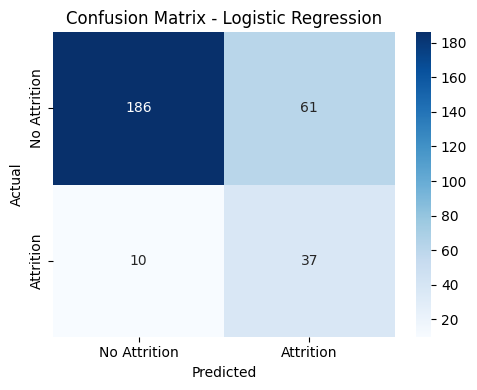

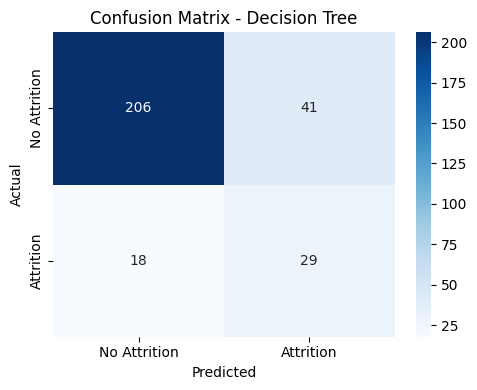

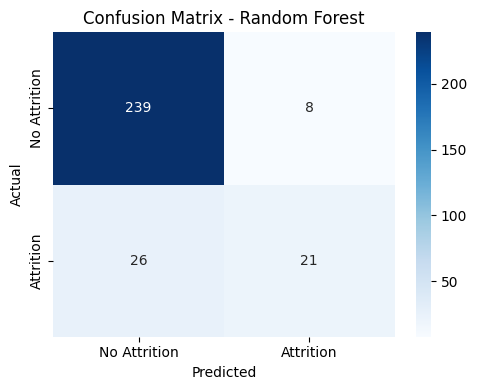

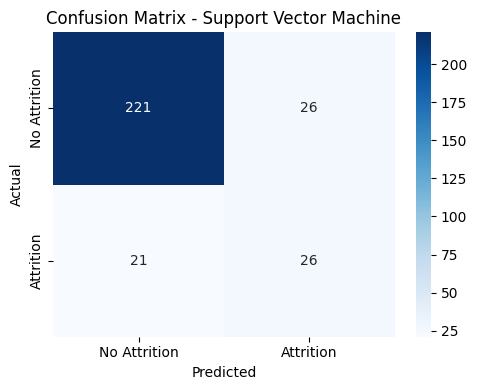

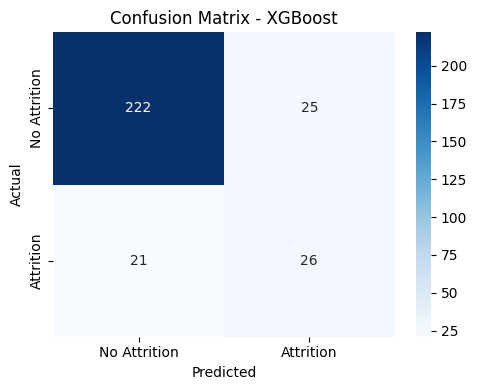

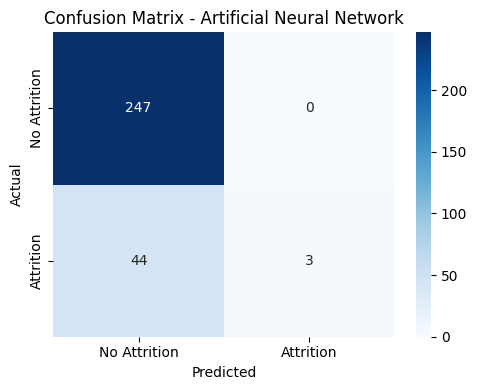

In [63]:
# plotting confusion matrix for class-weighted models
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Attrition", "Attrition"],
        yticklabels=["No Attrition", "Attrition"]
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [64]:
# creating confusion matrix summary table
confusion_summary = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    confusion_summary.append({
        "Model": model_name,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp
    })

confusion_summary_df = pd.DataFrame(confusion_summary)
confusion_summary_df

,Model,True Negative,False Positive,False Negative,True Positive
0,Logistic Regression,186,61,10,37
1,Decision Tree,206,41,18,29
2,Random Forest,239,8,26,21
3,Support Vector Machine,221,26,21,26
4,XGBoost,222,25,21,26
5,Artificial Neural Network,247,0,44,3


## ROC Curve

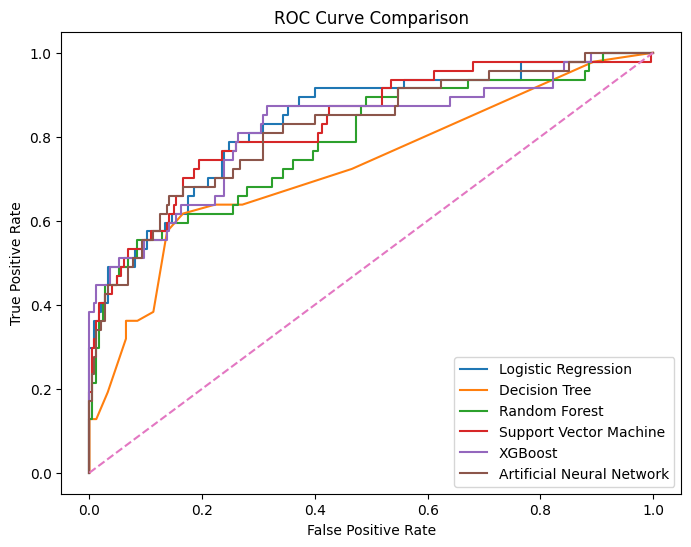

In [65]:
# plotting ROC curves
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Model Comparison

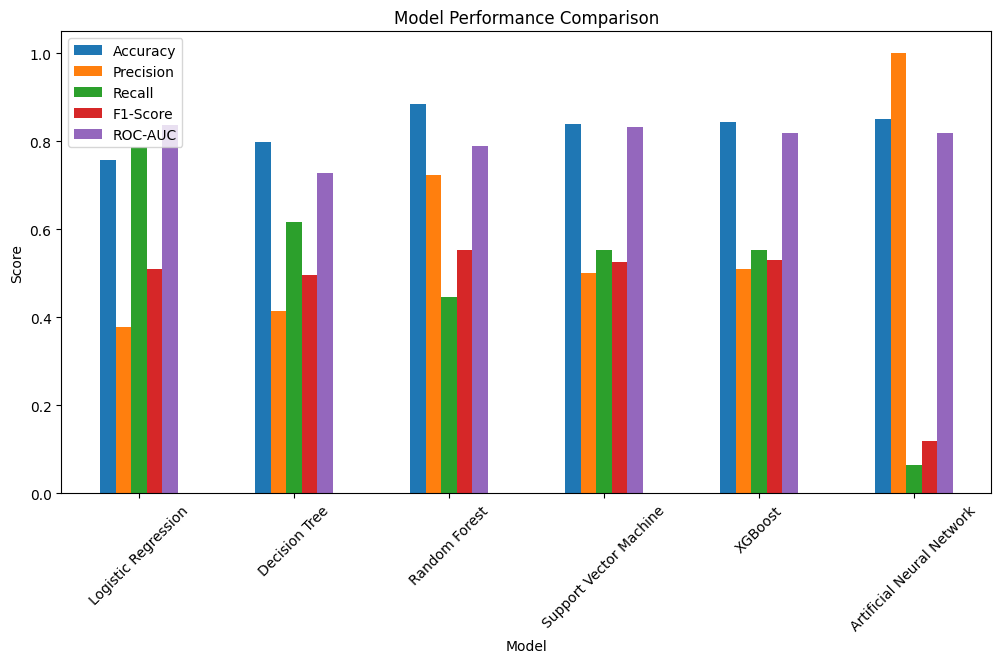

In [66]:
# plotting model comparison
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(kind='bar', figsize=(12,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

## Feature Importance using Randam Forest

In [67]:
1# extracting feature names after preprocessing
feature_names = models['Random Forest'].named_steps['preprocessor'].get_feature_names_out()
importances = models['Random Forest'].named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(15)

,Feature,Importance
9,num__MonthlyIncome,0.070453
50,cat__OverTime_Yes,0.062700
0,num__Age,0.061579
49,cat__OverTime_No,0.054838
16,num__TotalWorkingYears,0.053004
19,num__YearsAtCompany,0.049811
1,num__DailyRate,0.045048
2,num__DistanceFromHome,0.041934
5,num__HourlyRate,0.039684
10,num__MonthlyRate,0.039239


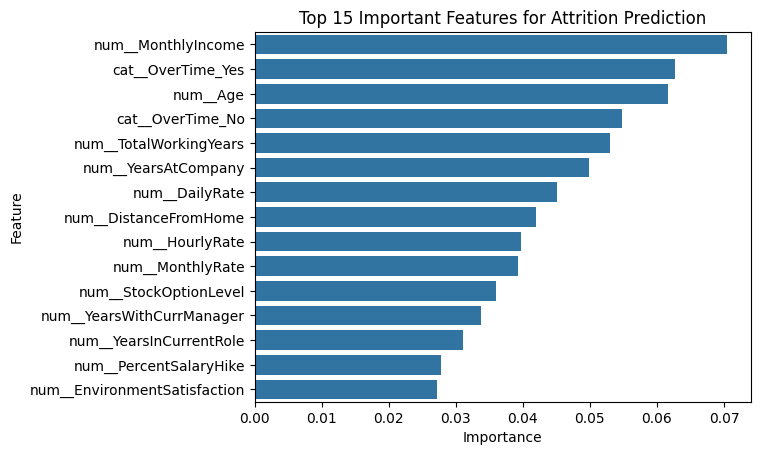

In [68]:
# plotting top important features
top_features = feature_importance_df.head(15)

sns.barplot(data=top_features, x='Importance', y='Feature')
plt.title("Top 15 Important Features for Attrition Prediction")
plt.show()

## Feature Importance Using XGBoost

In [69]:
# extracting feature names and xgboost feature importance
xgb_preprocessor = models["XGBoost"].named_steps["preprocessor"]
xgb_classifier = models["XGBoost"].named_steps["classifier"]

xgb_feature_names = xgb_preprocessor.get_feature_names_out()
xgb_importances = xgb_classifier.feature_importances_

In [70]:
# creating xgboost feature importance dataframe
xgb_feature_importance_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_importances
}).sort_values(by="Importance", ascending=False)

xgb_feature_importance_df["Feature"] = (
    xgb_feature_importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

xgb_feature_importance_df.head(20)

,Feature,Importance
50,OverTime_Yes,0.099178
49,OverTime_No,0.051406
7,JobLevel,0.048196
44,JobRole_Sales Executive,0.044354
19,YearsAtCompany,0.030888
15,StockOptionLevel,0.027277
0,Age,0.022822
23,BusinessTravel_Non-Travel,0.022530
24,BusinessTravel_Travel_Frequently,0.022287
16,TotalWorkingYears,0.022155


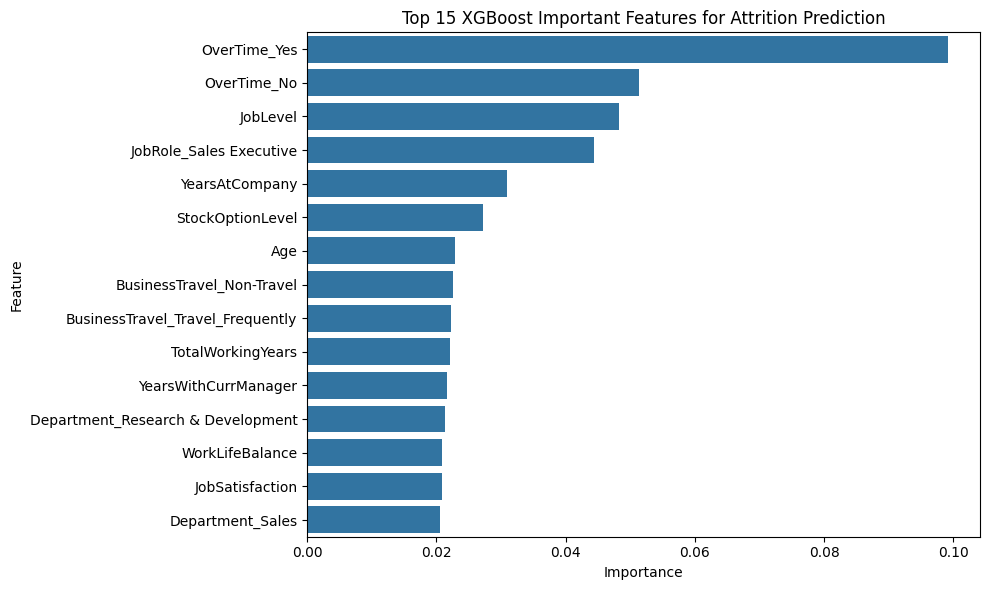

In [71]:
# plotting top 15 xgboost important features
top_xgb_features = xgb_feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_xgb_features, x="Importance", y="Feature")
plt.title("Top 15 XGBoost Important Features for Attrition Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [72]:
# creating stratified cross validation for imbalanced classification
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=124)

In [73]:
# defining random forest tuning parameters with class weights
rf_param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [5, 8, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": ["balanced", "balanced_subsample"]
}

In [74]:
# tuning random forest using f1-score for minority class
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=124, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'DailyRate',
                                                                          'DistanceFromHome',
                                                                          'Education',
                                                                          'EnvironmentSatisfaction',
                                                                          'HourlyRate',
                                                                          'JobInvolvement',
                                                                          'JobLevel',
                                                                          'JobSatisfaction',
                                                                          'MonthlyIncome',
                                                                          'MonthlyRate',
                                                                          'NumCompanies...
                                        RandomForestClassifier(class_weight='balanced_subsample',
                                                               max_depth=8,
                                                               min_samples_leaf=2,
                                                               min_samples_split=5,
                                                               n_estimators=300,
                                                               n_jobs=-1,
                                                               random_state=124))]),
             n_jobs=-1,
             param_grid={'classifier__class_weight': ['balanced',
                                                      'balanced_subsample'],
                         'classifier__max_depth': [5, 8, 10],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [200, 300]},
             scoring='f1')

In [75]:
# displaying best random forest parameters
rf_grid.best_params_

{'classifier__class_weight': 'balanced_subsample',
 'classifier__max_depth': 5,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 200}

In [76]:
# displaying best random forest f1-score
rf_grid.best_score_

np.float64(0.5156651445966515)

In [77]:
# defining xgboost tuning parameters with class imbalance weight
xgb_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [3, 4, 5],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__scale_pos_weight": [scale_pos_weight]
}

In [78]:
# tuning xgboost using f1-score for minority class
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=124, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'DailyRate',
                                                                          'DistanceFromHome',
                                                                          'Education',
                                                                          'EnvironmentSatisfaction',
                                                                          'HourlyRate',
                                                                          'JobInvolvement',
                                                                          'JobLevel',
                                                                          'JobSatisfaction',
                                                                          'MonthlyIncome',
                                                                          'MonthlyRate',
                                                                          'NumCompanies...
                                                      multi_strategy=None,
                                                      n_estimators=300,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__colsample_bytree': [0.8, 1.0],
                         'classifier__learning_rate': [0.03, 0.05, 0.1],
                         'classifier__max_depth': [3, 4, 5],
                         'classifier__n_estimators': [100, 200, 300],
                         'classifier__scale_pos_weight': [np.float64(5.189473684210526)],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='f1')

In [79]:
# displaying best xgboost parameters
xgb_grid.best_params_

{'classifier__colsample_bytree': 0.8,
 'classifier__learning_rate': 0.05,
 'classifier__max_depth': 3,
 'classifier__n_estimators': 300,
 'classifier__scale_pos_weight': np.float64(5.189473684210526),
 'classifier__subsample': 0.8}

In [80]:
# displaying best xgboost cross validation score
xgb_grid.best_score_

np.float64(0.545527136331734)

In [81]:
ann_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        random_state=124
    ))
])

In [82]:
# displaying best ann parameters
print("Best ANN Parameters:", ann_grid.best_params_)

# displaying best ann f1-score
print("Best ANN F1-Score:", ann_grid.best_score_)

Best ANN Parameters: {'classifier__activation': 'relu', 'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (128, 64), 'classifier__learning_rate_init': 0.01, 'classifier__solver': 'adam'}
Best ANN F1-Score: 0.4891379132763415


## Evaluate Tuned Models

In [83]:
# storing tuned models
tuned_models = {
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned XGBoost": xgb_grid.best_estimator_,
    "Tuned ANN": ann_grid.best_estimator_ # Add the tuned ANN model
}

# evaluating tuned class-weighted models
tuned_results = []

for model_name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.843537,0.509804,0.553191,0.530612,0.788182
1,Tuned XGBoost,0.843537,0.509804,0.553191,0.530612,0.818158
2,Tuned ANN,0.867347,0.642857,0.382979,0.480000,0.819364


In [84]:
# evaluating tuned class-weighted models
tuned_results = []

for model_name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.843537,0.509804,0.553191,0.530612,0.788182
1,Tuned XGBoost,0.843537,0.509804,0.553191,0.530612,0.818158
2,Tuned ANN,0.867347,0.642857,0.382979,0.480000,0.819364


In [85]:
# combining original and tuned class-weighted model results
final_results_df = pd.concat(
    [pd.DataFrame([baseline_results]), results_df, tuned_results_df],
    ignore_index=True
)

final_results_df.sort_values(by=["F1-Score", "Recall"], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Random Forest,0.884354,0.724138,0.446809,0.552632,0.789043
5,XGBoost,0.843537,0.509804,0.553191,0.530612,0.818158
7,Tuned Random Forest,0.843537,0.509804,0.553191,0.530612,0.788182
8,Tuned XGBoost,0.843537,0.509804,0.553191,0.530612,0.818158
4,Support Vector Machine,0.840136,0.500000,0.553191,0.525253,0.831768
1,Logistic Regression,0.758503,0.377551,0.787234,0.510345,0.838401
2,Decision Tree,0.799320,0.414286,0.617021,0.495726,0.727711
9,Tuned ANN,0.867347,0.642857,0.382979,0.480000,0.819364
6,Artificial Neural Network,0.850340,1.000000,0.063830,0.120000,0.818675
0,Baseline Dummy Classifier,0.840136,0.000000,0.000000,0.000000,0.500000


## Final Model Selection

In [86]:
# selecting best model using f1-score because dataset is imbalanced
best_model_name = final_results_df.sort_values(
    by=["F1-Score", "Recall"],
    ascending=False
).iloc[0]["Model"]

best_model_name

'Random Forest'

In [87]:
# selecting best class-weighted model object
all_model_objects = {}
all_model_objects.update(models)
all_model_objects.update(tuned_models)

best_model = all_model_objects[best_model_name]
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=8, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=300,
                                        n_jobs=-1, random_state=124))])

In [88]:
# generating final predictions using selected best model
final_y_pred = best_model.predict(X_test)
final_y_prob = best_model.predict_proba(X_test)[:, 1]

In [89]:
# displaying final classification report
print(classification_report(
    y_test,
    final_y_pred,
    target_names=["No Attrition", "Attrition"],
    zero_division=0
))

              precision    recall  f1-score   support

No Attrition       0.90      0.97      0.93       247
   Attrition       0.72      0.45      0.55        47

    accuracy                           0.88       294
   macro avg       0.81      0.71      0.74       294
weighted avg       0.87      0.88      0.87       294



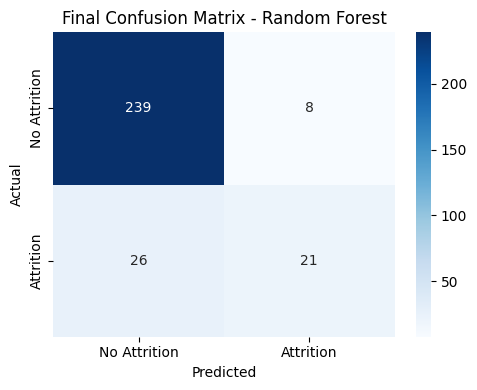

In [90]:
# plotting final confusion matrix
final_cm = confusion_matrix(y_test, final_y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)
plt.title(f"Final Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Prediction on New Employee Data

In [91]:
# predicting attrition for sample employee
hypothetical_employees = df_model.drop('Attrition', axis=1).sample(n=10, random_state=124)
sample_employee = hypothetical_employees
sample_employee

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1160,45,Travel_Rarely,1329,Research & Development,2,2,Other,4,Female,59,...,3,1,2,10,3,3,10,7,3,9
684,40,Travel_Rarely,658,Sales,10,4,Marketing,1,Male,67,...,3,2,1,11,2,2,1,0,0,0
1301,58,Non-Travel,350,Sales,2,3,Medical,2,Male,52,...,4,4,1,37,0,2,16,9,14,14
1450,35,Travel_Rarely,1146,Human Resources,26,4,Life Sciences,3,Female,31,...,3,3,0,9,2,3,9,0,1,7
1033,31,Travel_Frequently,1445,Research & Development,1,5,Life Sciences,3,Female,100,...,3,1,0,10,2,3,10,8,4,7
992,39,Non-Travel,1485,Research & Development,25,2,Life Sciences,3,Male,71,...,4,2,1,13,2,3,6,4,0,5
636,35,Travel_Frequently,130,Research & Development,25,4,Life Sciences,4,Female,96,...,3,1,1,10,3,2,10,2,7,8
442,36,Non-Travel,635,Sales,10,4,Medical,2,Male,32,...,3,4,0,10,3,2,10,3,9,7
207,36,Travel_Frequently,635,Research & Development,18,1,Medical,2,Female,73,...,3,1,0,8,2,3,8,1,1,7
1126,50,Travel_Rarely,264,Sales,9,3,Marketing,3,Male,59,...,3,3,1,27,2,3,1,0,0,0


In [92]:
# predicting attrition for sample employee
sample_prediction = best_model.predict(sample_employee)
sample_probability = best_model.predict_proba(sample_employee)[:, 1]
for i in range(len(sample_employee)):
    print(f"Employee {i+1} Prediction: {'Attrition' if sample_prediction[i] == 1 else 'No Attrition'}")
    print(f"Employee {i+1} Attrition Probability: {sample_probability[i]:.4f}")
    print("----------------------------------------")

Employee 1 Prediction: No Attrition
Employee 1 Attrition Probability: 0.0912
----------------------------------------
Employee 2 Prediction: No Attrition
Employee 2 Attrition Probability: 0.2226
----------------------------------------
Employee 3 Prediction: No Attrition
Employee 3 Attrition Probability: 0.1345
----------------------------------------
Employee 4 Prediction: No Attrition
Employee 4 Attrition Probability: 0.2978
----------------------------------------
Employee 5 Prediction: Attrition
Employee 5 Attrition Probability: 0.5201
----------------------------------------
Employee 6 Prediction: No Attrition
Employee 6 Attrition Probability: 0.1056
----------------------------------------
Employee 7 Prediction: Attrition
Employee 7 Attrition Probability: 0.5111
----------------------------------------
Employee 8 Prediction: No Attrition
Employee 8 Attrition Probability: 0.2637
----------------------------------------
Employee 9 Prediction: No Attrition
Employee 9 Attrition Proba

In [93]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

Create the deployment files

In [94]:
%%writefile requirements.txt
streamlit==1.49.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.5.3

Overwriting requirements.txt


In [95]:
%%writefile README.md
# Employee Attrition Prediction

This project predicts whether an employee is likely to leave the company using Machine Learning.

Best Model: Random Forest

Overwriting README.md


In [96]:
%%writefile app.py

import streamlit as st

st.title("Employee Attrition Prediction")

Overwriting app.py


In [97]:
import sklearn
import joblib
import pandas
import numpy

print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)

sklearn: 1.6.1
joblib: 1.5.3
pandas: 2.2.2
numpy: 2.0.2
